<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/> 

# Statistics for Feature Selection in Machine Learning
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

# Statistics the context of  Feature Selection

Now that we've introduced statistical concepts we'll now focus on some of the motivation behind why we might apply these in machine learning in particular we will looks at the ***feature selection*** process

Contrary to popular belief, adding more feature to your dataset doesn't always make your model better. In fact, adding irrelevant features can actually make your model worse and make model training more computationally expensive. This is where feature selection comes in.

---
---
# Overfitting and Undefitting
---
---


### 1. Underfitting (Feature Deficiency)

The model is too simple because it doesn't have enough "information" to see the full picture.

* **Too few features** or the **wrong features**. If you try to predict a house's price using *only* its color, the model will fail because it’s missing the critical "engines" of value like square footage or location.

* **The Result:** High error on both training and new data. Even the best model can't find a pattern if the features provided don't actually relate to the target.



### 2. Overfitting (Feature Inflation)

The model is too flexible because it has too many "distractions" to choose from.

* **Too many features** relative to the number of samples. When you have an abundance of features—especially "noisy" ones like *Customer ID* or *Time of Entry (to the second)*—the model stops looking for general trends and starts creating a unique "fingerprint" for every row.

* **The Result:** Perfect accuracy on training data but failure on new data. The model "memorized" a specific person (e.g., *"Everyone who wore red shoes today bought a hat"*) instead of a general rule (e.g., *"It's sunny out"*).

### Desired: The "Goldilocks" Feature Set

The ideal model has just the right amount of relevant features to capture the underlying patterns without getting distracted by noise. This balance allows it to perform well on both training and unseen data, making it a reliable tool for predictions.

---
---
# Univariate Feature Selection
---
---

We will examine the process of univariate feature selection which is a method of selecting features based on their individual relationship with the target variable. This is often done using statistical tests to determine which features are most relevant for predicting the target variable.

we will consider: 

    - continuous vs continuous features
    - categorical vs categorical features
    - categorical vs continuous features




---
# Non-Parametric Tests vs Parametric Tests
---


### The Core Difference

* **Parametric Tests:** Assume your data follows specific assumptions (like a Normal distribution). They often use the actual values of your data to calculate things like means and variances.

* **Non-parametric Tests:** "Distribution-free" tests. They don't assume any specific data distribution and often rely on the ranks or order of the data rather than the actual values.



### Comparison Table

| Feature | Parametric Tests | Non-parametric Tests |
| --- | --- | --- |
| **Data Assumption** | Assumes a Normal/Bell Curve. | No assumptions about data shape. |
| **Data Type** | Best for continuous, clean numbers. | Best for "messy" data or rankings. |
| **Sensitivity** | Highly precise with "perfect" data. | Robust; works well with outliers. |
| **Typical Goal** | Compare means (averages). | Compare medians or ranks. |
| **Examples** | Pearson Correlation, ANOVA | Spearman Correlation, Chi-Square. |


### When to use which?

 **Use Parametric** if your data meet the required assumptions, then use the parametric tests. These are more "powerful" at finding subtle relationships between features otherwise opt for non-parametric tests which are more "forgiving" when your data is messy or doesn't fit the ideal assumptions.




---
---
# 1. Continuous vs Continuous Features
---
---

with exception of spearman's correlation, for this notebook, we will be looking mainly at the parametric tests only. However, we will look at the underlying process of how spearman's correlation works to understand why it is a non-parametric test to better understand the non-parametric tests in general.

---
## Correlations - Pearson's does not always have the full story


Text(0.5, 1.0, 'Practice Hours vs Performance')

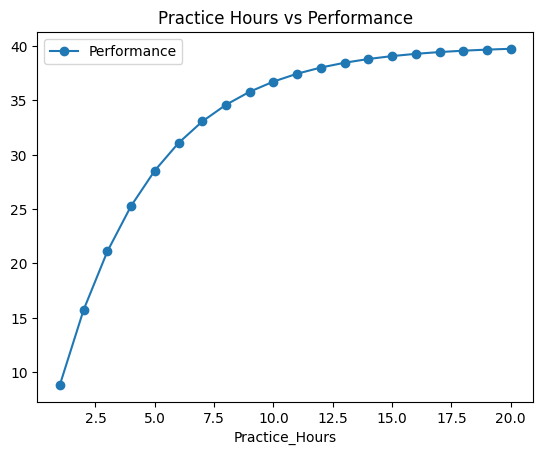

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


x = np.arange(1, 21)                     # Practice hours
y = 40 * (1 - np.exp(-x/4))              # Saturating curve (diminishing returns)

df = pd.DataFrame({'Practice_Hours': x, 'Performance': y})

# df plots with line connecting the points
df.plot(x='Practice_Hours', y='Performance', marker='o')
plt.title('Practice Hours vs Performance')

In [2]:
df.corr()


,Practice_Hours,Performance
Practice_Hours,1.000000,0.859913
Performance,0.859913,1.000000


By default, the `corr()` method in pandas uses Pearson's correlation

In [4]:
#.corr for pearson method
df.corr(method='pearson')

,Practice_Hours,Performance
Practice_Hours,1.000000,0.859913
Performance,0.859913,1.000000


### The correlations above are the same!

In [5]:
#.corr for spearman method
df.corr(method='spearman')

,Practice_Hours,Performance
Practice_Hours,1.0,1.0
Performance,1.0,1.0


woah it seems like the spearmans correlation was able to perfectly capture the relationship between X and Y?

### Why are are the two correlations so different?

---

# HINT

# Pearson's:

** Main Assumptions** : 

 - Linear relationship between variables,
 - Continuous and Normally Distributed Variables 
 - Equal Variance (Homoscedasticity) of the Variables

# Spearman's:

 *** Main Assumptions***: Monotonic relationship between variables,
                    No assumptions about the distribution of the data

Before we dive into the details of the how spearman's correlation works, let's first see how the presence of an outlier affect the Pearson's correlation and the Spearman's correlation

---
#  Pearson's vs Spearman's Correlation and Outliers
---

lets first create a near perfect Correlation and see what happens when we add an outlier to the data

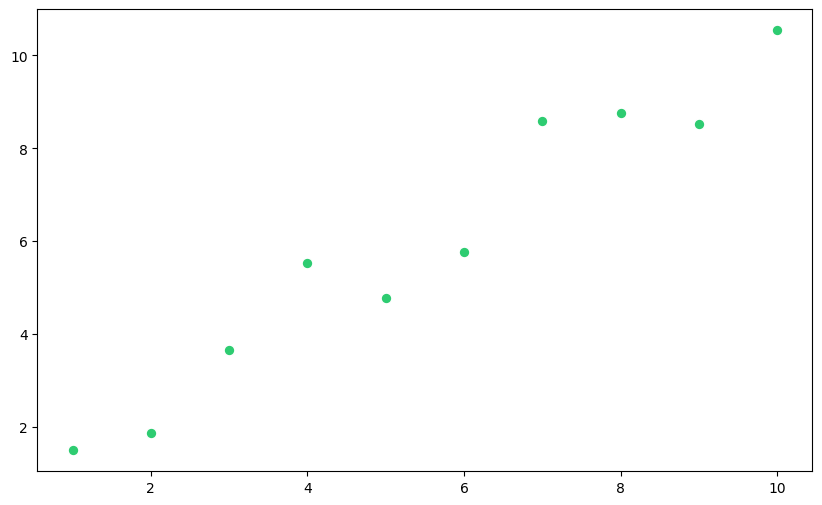

In [6]:
# Generate Data
np.random.seed(42)
x = np.linspace(1, 10, 10)
y = x + np.random.normal(0, 1, 10)

# Create DataFrame and Calculate Correlations
df = pd.DataFrame({'X': x, 'Y': y})

# Create the Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['X'], df['Y'], color='#2ecc71', edgecolor='white', s=60, label='Data Points')


In [8]:
# pearson .corr
df.corr(method='pearson')

,X,Y
X,1.000000,0.972308
Y,0.972308,1.000000


r = 0.97 almost perfect correlation

Now lets add an outlier to the data and see what happens to the correlation

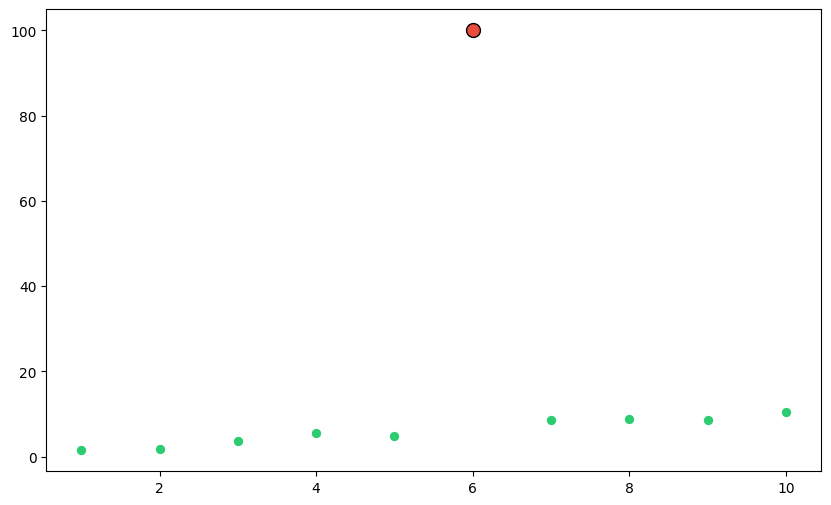

In [9]:
# 1. Generate Data
np.random.seed(42)
x = np.linspace(1, 10, 10)
y = x + np.random.normal(0, 1, 10)
# Adding the outlier
y[5] = 100

# 2. Create DataFrame and Calculate Correlations
df = pd.DataFrame({'X': x, 'Y': y})

# 3. Create the Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['X'], df['Y'], color='#2ecc71', edgecolor='white', s=60, label='Data Points')
plt.scatter(df['X'][5], df['Y'][5], color='#e74c3c', s=100, label='The Outlier', edgecolor='black')


In [10]:
# check our pearson correlation again after adding the outlier
df.corr(method='pearson')

,X,Y
X,1.000000,0.158414
Y,0.158414,1.000000


ouu it seems like the correlation has dropped significantly, this is because Pearson's correlation is sensitive to outliers. The outlier has a disproportionate influence on the overall data, which can skew the results and lead to a much lower correlation coefficient. This is one of the reasons why it's important to check for outliers in your data before applying Pearson's correlation, as they can significantly affect the results.

Now let us see how spearman's correlation handles outliers in the same data.

In [12]:
# lets check spearman's
df.corr(method='spearman')

,X,Y
X,1.000000,0.830303
Y,0.830303,1.000000


---
# Ranking and Spearman's Correlation
---

spearmans correlation is more robust to outliers because it uses the rank of the data rather than the actual values. This means that even if there is an outlier in the data, it will not have as much of an influence on the overall correlation coefficient as it would in Pearson's correlation. In this case, we would expect to see a much higher correlation coefficient with Spearman's correlation compared to Pearson's correlation, indicating that there is still a strong relationship between the two variables despite the presence of the outlier.

In [13]:
# 3. Assign X Ranks
print('X values')
print(' ')
print(df['X'].to_list())
print('')
print("X Rankings:")
print('')
print(df['X'].rank().astype(int).to_list())

X values
 
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

X Rankings:

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [14]:
# 2. Assign y Ranks
print('y values')
print(' ')
print(df['Y'].to_list())
print('')
print("y Rankings:")
print('')
print(df['Y'].rank().astype(int).to_list())

y values
 
[1.4967141530112327, 1.8617356988288154, 3.6476885381006925, 5.523029856408026, 4.765846625276664, 100.0, 8.579212815507391, 8.767434729152908, 8.530525614065049, 10.542560043585965]

y Rankings:

[1, 2, 3, 5, 4, 10, 7, 8, 6, 9]


## Notice that once the ranks are assigned, the outlier is no longer an outlier in terms of its rank!

---
# **Thought**: Why Bother with Pearson's Correlation if Spearman's is more robust to outliers and even capture non-linear relationships?
---

The answer is that pearson's correlation can be more powerful when the assumptions are met. If your data is normally distributed and has a linear relationship, Pearson's correlation can provide a more accurate measure of the strength of the relationship between the two variables. Additionally, it is more sensitive to subtle relationships between variables that may not be captured by Spearman's correlation.

<Axes: xlabel='X', ylabel='Y'>

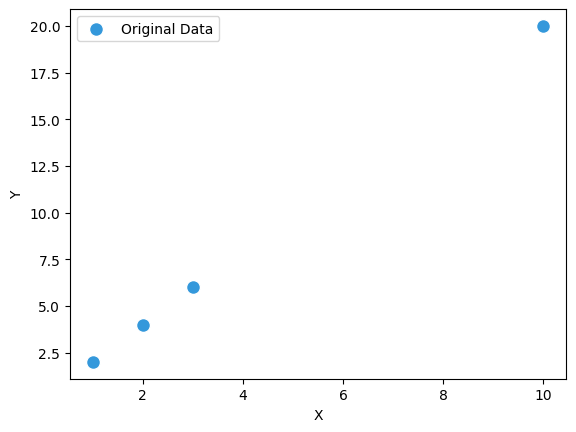

In [16]:
# let make a perfectly linear relationship
data_original = {
    'X': [1,2,3,10],
    'Y': [2,4,6,20]
}

df1 = pd.DataFrame(data_original)
df1.plot(kind='scatter', x='X', y='Y', color='#3498db', edgecolor='white', s=100, label='Original Data')


In [17]:
# verify our pearson correlation is 1
df1.corr(method='pearson')

,X,Y
X,1.0,1.0
Y,1.0,1.0


In [18]:
# verify our spearman correlation is 1
df1.corr(method='spearman')

,X,Y
X,1.0,1.0
Y,1.0,1.0


<Axes: xlabel='X', ylabel='Y'>

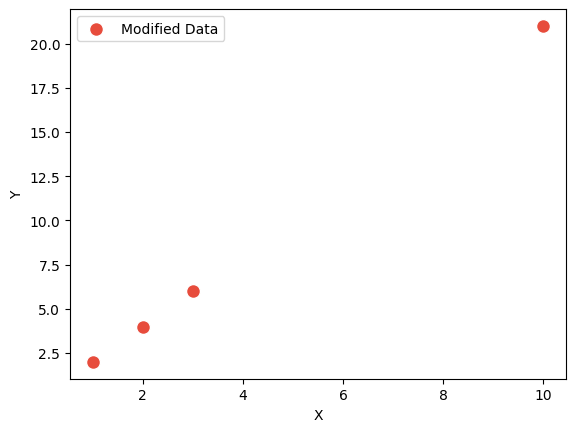

In [20]:
# Now lets a add a slight change to the last point to see how it affects our correlations
data_modified = {
    'X': [1,2,3,10],
    'Y': [2,4,6,21]
}

df2 = pd.DataFrame(data_modified)
df2.plot(kind='scatter', x='X', y='Y', color='#e74c3c', edgecolor='white', s=100, label='Modified Data')

In [21]:
# spearman's correlation is still 1 because the ranks are the same
df2.corr(method="spearman")

,X,Y
X,1.0,1.0
Y,1.0,1.0


In [22]:
# pearson's correlation is no longer 1 it was very sensitive to the change in the last point although the change was small hence it being more powerful than spearman's
df2.corr(method='pearson')

,X,Y
X,1.000000,0.999933
Y,0.999933,1.000000


###  Pearson's correlation was able to detect a minor deviation from linearity - displaying the power of Pearson's correlation in capturing subtle linear relationships that Spearman's might miss due to its focus on ranks rather than actual values.

# In summary

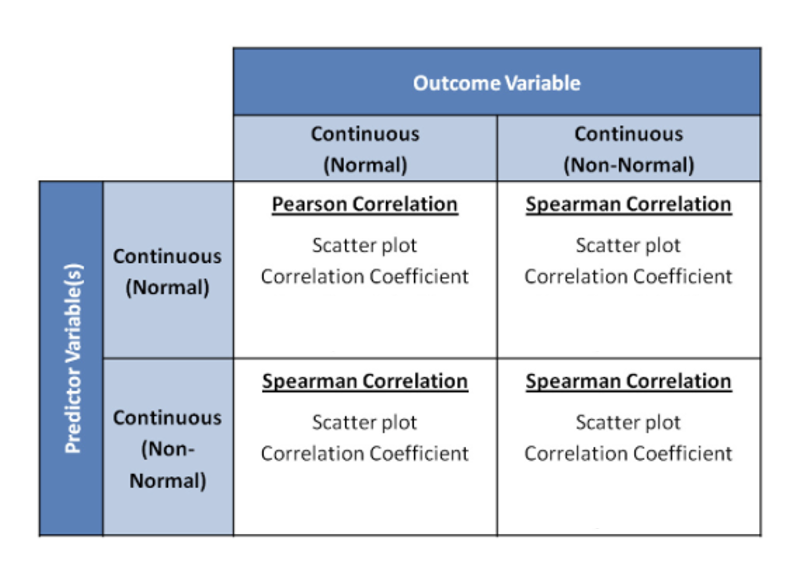

# Decision:

Keep features with a strong correlation to the target variable, but also consider the context of the data and the assumptions of the tests being used. If the data is messy or doesn't meet the assumptions of parametric tests, non-parametric tests like Spearman's correlation can provide valuable insights without being skewed by outliers.

# Exercise Activity 1

---
---
# Features Selection - Categorical vs Categorical 
---
--- 

- We cannot use correlations to identify relationships between two categorical variables, as correlations are designed for continuous data. Instead, we can use other statistical methods such as the Chi-Square test  strength of association between two categorical variables. 

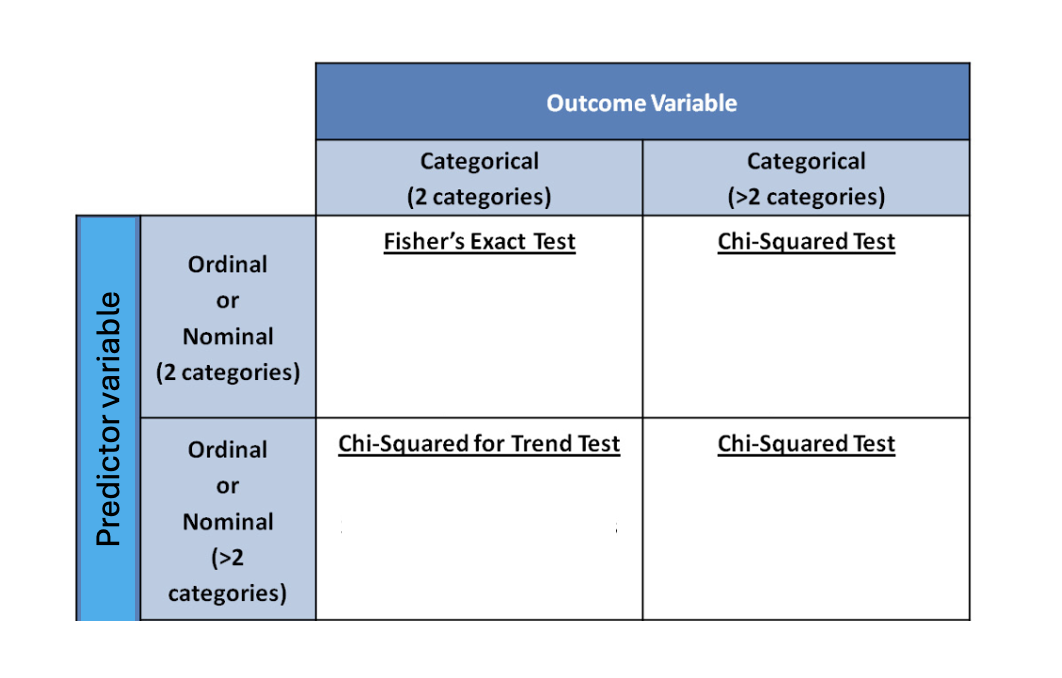


## 1. The Assumptions

Before you run the test, your data needs to check these boxes:

* **Categorical Data:** Your variables must be nominal (e.g., hair color) or ordinal (e.g., "satisfied," "neutral," "unsatisfied").
* **Independence:** Each observation must be independent. You can’t count the same person twice.
* **Random Sampling:** Data should be collected through a random process.
* **Large Enough Sample:** The "Expected Frequency" in each cell of your table should be at least 5. If it’s smaller, the math gets a bit shaky***






## 2. The Null Hypothesis 

**Formally:** The null hypothesis states that there is **no significant association** between the two categorical variables in the population. Any observed difference is due to chance.

**In Plain English:** "There is nothing special going on here; these two things have nothing to do with each other."

### Examples:

* **Example 1 (Coffee & Productivity):**  = Drinking coffee is **not** related to whether a person finishes their tasks on time.

| Group | Finished Task On Time | Did Not Finish On Time | **Total** |
| :--- | :---: | :---: | :---: |
| **Coffee Drinkers** | 42 | 8 | **50** |
| **Non-Coffee Drinkers** | 15 | 35 | **50** |
| **Total** | **57** | **43** | **100** |




* **Example 2 (Gym Membership & Age):**  = A person’s age group has **no effect** on whether they have a gym membership.

| Age Bracket | Has Gym Membership | No Gym Membership | **Total** |
| :--- | :---: | :---: | :---: |
| **Under 30** | 48 | 52 | **100** |
| **30 to 60** | 46 | 54 | **100** |
| **Over 60** | 44 | 56 | **100** |
| **Total** | **138** | **162** | **300** |





## 3. The Alternative Hypothesis 

**Formally:** The alternative hypothesis states that there **is a significant association** between the two categorical variables.

**In Plain English:** "There is a real connection here; one variable seems to influence the other."

### Examples (The Outcomes):

* **Example 1 (Accepted ):** We find a connection! **Result:** People who drink coffee are significantly more likely to finish tasks on time than those who don't. We **reject** the null.


* **Example 2 (Rejected ):** We found nothing. **Result:** Younger people and older people sign up for gyms at roughly the same rate. We **fail to reject** the null.




## 4. Major Caveat

Chi-Squared is powerful, but it has "blind spots" you need to know:

* **No Location/Direction:** It tells you *that* an association exists, but not *where* or *how*. If you have a 3x3 table, it won't tell you which specific group is causing the spark.



---
---

# Example: Chi-Squared Test -  3 ordinal categories (predictor) vs 2 categories (outcome)

---
---



We are checking if **dosage** and **recovery** are linked. We have three different doses and two possible outcomes. We want to know if the recovery rates change depending on the dose, or if everyone has the same chance of getting better regardless of the pill they took.

### **Null Hypothesis**

In plain English, the Null Hypothesis assumes the dose and the outcome are **independent**. This means the medicine has no effect; your chance of recovering is the same whether you took the Placebo or the High Dose.

### **Alternative Hypothesis**

In plain English, the Alternative Hypothesis assumes the dose and the outcome are **dependent**. This means the medicine *does* have an effect, and knowing which dose a patient took actually helps you predict if they will get better.



In [23]:
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

data = np.array([
    [10, 90],  # Placebo: 10% improvement
    [15, 85],  # Low Dose: 15% improvement
    [21, 79]   # High Dose: 21% improvement
])

df_contingency= pd.DataFrame(data, columns=['Improved', 'No Change'], 
                              index=['Placebo', 'Low Dose', 'High Dose'])


In [31]:
from scipy.stats.contingency import association
association(df_contingency, method="cramer")


0.12480728039930605

In [24]:
# view the contingency table
df_contingency

,Improved,No Change
Placebo,10,90
Low Dose,15,85
High Dose,21,79


In [25]:
# 1. Standard Chi-Squared (Nominal - treats groups as independent buckets)
chi2, p_nominal, dof, expected = chi2_contingency(df_contingency)

print(f"\nStandard Chi-Squared P-value: {p_nominal:.4f} (Not Significant at alpha 0.05)")


Standard Chi-Squared P-value: 0.0967 (Not Significant at alpha 0.05)


---
---
# USING THE CHI-SQUARED TEST FOR TREND
---
---


We are testing if there is a **steady upward trend** between the dose of medicine and a patient's recovery. Instead of just asking "is there any difference," we are asking: "Does the recovery rate consistently improve as we move from Placebo to Low Dose to High Dose?" This test treats the dosage like a ladder, where each step up should ideally lead to better results.

### **Null Hypothesis**

In plain English, the Null Hypothesis assumes there is **no consistent trend**. It claims that increasing the dose does not steadily increase the chance of getting better. Even if one group looks a little higher, the test assumes there is no reliable "climb" or "slope" in the results.


### **Alternative Hypothesis**

In plain English, the Alternative Hypothesis assumes there is a **real, predictable trend**. It claims that as the dosage increases, the likelihood of recovery also increases (or decreases) in a consistent way. If this is true, it proves that "more medicine" generally equals "better results."



### **Why this is "Smarter" than the basic test**

* **The Basic Chi-Square** is like asking: "Are these three groups different?" (It doesn't care about the order).
* **The Trend Test** is like asking: "Is there a Dose-Response relationship?" (It relies on the order).

If your success rates are **10%  15%  21%**, the Trend Test is much more powerful because it sees that pattern. A regular Chi-Square might miss a subtle pattern that a Trend Test will catch.

In [26]:
# 2. Chi-Squared for Trend (Ordinal - treats groups as a ladder 0, 1, 2)
table = Table(data)
res_trend = table.test_ordinal_association()
p_trend = res_trend.pvalue

print(f"Chi-Squared for Trend P-value: {p_trend:.4f} (Significant at alpha 0.05)")

Chi-Squared for Trend P-value: 0.0311 (Significant at alpha 0.05)


Whilst generally used for all cases of categorical vs categorical data, the standard Chi-Squared test (which treats groups as independent buckets) may not show a significant association due to the relatively small differences in success rates across the groups. However, the Chi-Squared test for trend (which treats the groups as an ordinal ladder) may reveal a significant trend in the data, indicating that as the dose increases, the likelihood of improvement also increases. This illustrates how considering the ordinal nature of the predictor variable can provide additional insights.

**Decision:** "Because we found a significant trend, we will keep the feature and use **Ordinal Encoding**. This allows the model to 'see' the ladder/pattern we discovered in our statistical test."



# Exercise Activity 2

---
---
# Features Selection - Categorical vs Continuous and Vice Versa
---
---

Carrying out the F-test (ANOVA) to compare the means of the "Income" feature between the two groups defined by the "Default" variable.

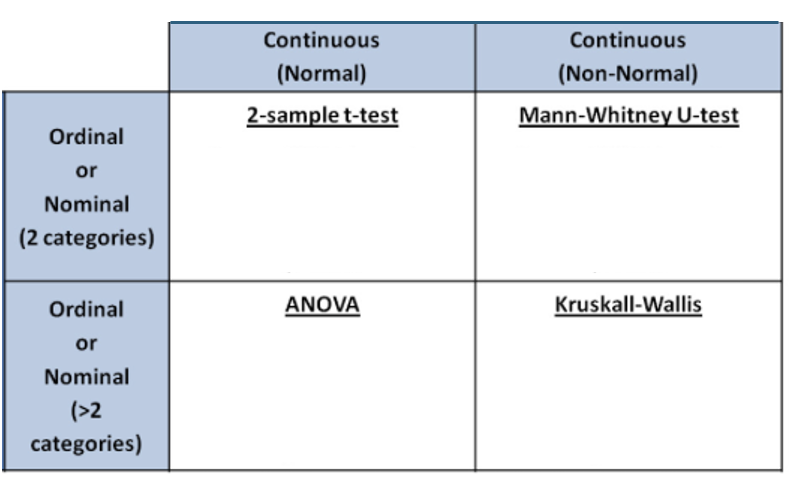

---
---

# ANOVA 

---
---

## 1. The Assumptions

To trust an ANOVA result, your data must meet these criteria:

* **Continuous Dependent Variable:** Your "target" must be a measurement (e.g., height, test scores, salary).
* **Categorical Independent Variable:** Your "groups" must be categories (e.g., Diet A, B, and C).
* **Independence of Observations:** No overlap between groups; one person can't be in two categories.
* **Normality:** The data within each group should roughly follow a bell curve (Normal distribution).
* **Homogeneity of Variance:** The "spread" (standard deviation) of the data should be roughly equal across all groups.





## 2. The Null Hypothesis ()

**Formally:** . The means of all groups are equal.

**In Plain English:** "There is no real difference between the groups. Any slight variation in their averages is just a fluke."

### Example 1: Two Groups (Special Case)

*Technically, with only two groups, you can use a t-test, but ANOVA works exactly the same way here.*

* **Scenario:** Testing a New Fertilizer vs. No Fertilizer on plant height.
* **:** The average height of plants with fertilizer is **the same** as the average height of plants without it.

### Example 2: Three Groups

* **Scenario:** Comparing the starting salaries of graduates from three different majors (Art, Engineering, Business).
* **:** The average starting salary is **exactly the same** across all three majors.





## 3. The Alternative Hypothesis ()

**Formally:** 

**In Plain English:** "At least one of these groups is doing something different than the others."

### The Outcomes

* **Example 1 (Accepted ):** We find a significant difference. **Result:** The fertilized plants grew significantly taller than the unfertilized ones.
* **Example 2 (Rejected ):** We found no significant difference. **Result:** In our specific sample, Art, Engineering, and Business majors all started at roughly the same salary.




## 4. Major Caveat:


If you have 3 groups (A, B, and C) and the ANOVA says "Significant!", it **does not** tell you which groups are different. It could be that:

1. A is different from B.
2. B is different from C.
3. All three are different from each other.

To find out "where" the difference is, you must run a **Post-Hoc Test** (like Tukey’s HSD) after the ANOVA.





--- 
# **Scenario: Tier subscription and spending**
---

We are investigating whether a customer's **Subscription Tier** (Bronze, Silver, or Gold) actually influences how much money they spend. While it might seem like higher tiers should spend more, we need to determine if there is a real "signal" here or if the differences are just random variation. We use the ANOVA test to decide if the **Tier** feature is worth keeping for our predictive model or if it is just a distraction.


### **Null Hypothesis**

In plain English, the Null Hypothesis assumes the Tier doesn't actually matter and any differences in spending are just a coincidence. It claims that the average spending across all three groups is basically the same, and any gaps we see in our data are just random "noise." If this is true, the Tier feature is useless for our model.



### **Alternative Hypothesis**

In plain English, the Alternative Hypothesis assumes the Tier does make a real difference in how much people spend. It claims that at least one of the tiers has a significantly different spending average than the others. If this is true, the Tier is a valuable piece of information that our model should use to make better predictions.


In [32]:
import numpy as np
import pandas as pd
from scipy.stats import f_oneway


# 1. Setup
np.random.seed(42)
n_samples = 100

# 2. Generate Categorical Predictor (Subscription Tier)
tiers = ['Bronze', 'Silver', 'Gold']
sub_tier = np.random.choice(tiers, size=n_samples)

# 3. Generate Continuous Target (Total Spend)
# Logic: We bring means closer (100, 115, 130) and increase noise (60)
spend_map = {'Bronze': 100, 'Silver': 115, 'Gold': 130}
noise = np.random.normal(0, 60, n_samples) 

spend = np.array([spend_map[t] for t in sub_tier]) + noise
df = pd.DataFrame({"Tier": sub_tier, "Spend": spend})



In [33]:
# head of the dataframe
df.head(10)

,Tier,Spend
0,Gold,164.927368
1,Bronze,153.264908
2,Gold,183.659940
3,Gold,175.299868
4,Bronze,87.570047
5,Bronze,62.591356
6,Gold,39.510803
7,Silver,180.978819
8,Gold,119.336073
9,Gold,105.377001


In [35]:
# 4. Create the 'splits' by filtering Spend for each Tier
bronze = df[df['Tier'] == 'Bronze']['Spend']
silver = df[df['Tier'] == 'Silver']['Spend']
gold = df[df['Tier'] == 'Gold']['Spend']

In [42]:
# f_oneway handles the math for different n automatically
f_stat, p_val = f_oneway(bronze, silver, gold)

In [43]:
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.10f}")

F-statistic: 1.0589
P-value: 0.3508125725



> **"There is no real difference between these groups; any variation we see is just a coincidence."**


* "The Null Hypothesis assumes that the membership tiers are **meaningless**. It claims that whether a customer is Bronze, Silver, or Gold, their average spending will basically be the same."
* "If we see that Gold spent $5 more than Bronze in our small sample, the Null Hypothesis says: 'That’s just a random fluke. If you tested another 100 people, that difference would probably disappear.'"




---
---
**Decision:**

* **The Verdict:** **Discard this feature.**
* **The Reason:** The "Tier" column does not have a statistically significant relationship with "Spend." If we include it in a predictive model, the model might "overfit" by trying to find patterns in what we now know is just random noise.


---
---

# Exercise Activity 3